## Example 4b:
Tests the ability of the flow-matched model to jointly predict the aberrations and a more complicated object (two blobs of different diameters and intensities).

In [1]:
import logging
import math
import warnings

import numpy as np
import torch
import pytorch_lightning as pl
from lightning_fabric.utilities.warnings import PossibleUserWarning
from matplotlib import pyplot

In [2]:
# Silence a few nuisance warnings:
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=PossibleUserWarning)
warnings.filterwarnings("ignore", message="Starting from v1.9.0, `tensorboardX`")
warnings.filterwarnings("ignore", message=r".*isinstance\(treespec, LeafSpec\).*")

In [3]:
from cynosure.config_defaults import (
    get_default_training_config,
    get_default_simulation_config,
    get_default_optical_config,
    get_default_phase_config,
    get_default_amplitude_config,
    get_default_phase_prior,
    get_default_amplitude_prior,
    get_default_noise_config,
    get_default_velocity_config,
    get_default_blob_prior,
)
from cynosure.object_distribution import SampledKBlobs
from cynosure.utilities.training_utils import NoValidationBar
from cynosure.zstack_decoding import ZstackSolver_FlowMatching
from cynosure.zstack_decoding import SoftShellJitter

#### Simulation setup

In [4]:
train_cfg = get_default_training_config()
sim_cfg = get_default_simulation_config()
opt_cfg = get_default_optical_config()
amp_cfg = get_default_amplitude_config()
phase_prior = get_default_phase_prior()
amp_prior = get_default_amplitude_prior()
noise_cfg = get_default_noise_config()
vel_cfg = get_default_velocity_config()
blob_cfg = get_default_blob_prior()

# Tip/tilt are degenerate with translation, so exclude them from the phase basis
phase_cfg = get_default_phase_config(allowed_nm=tuple(
    (n, m) for n, m in get_default_phase_config().allowed_nm if n != 1
))

object_distrib = SampledKBlobs(sim_cfg, num_blobs=2, prior_cfg=blob_cfg)

In [5]:
rng_seed = 123
z_jitter = 1.5  # um
device = "cuda" if torch.cuda.is_available() else "cpu"

#### Solver setup and training

In [6]:
pl.seed_everything(rng_seed, workers=True)
solver = ZstackSolver_FlowMatching(
    train_cfg=train_cfg,
    sim_cfg=sim_cfg,
    optics_cfg=opt_cfg,
    phase_cfg=phase_cfg,
    amp_cfg=amp_cfg,
    phase_prior_cfg=phase_prior,
    amp_prior_cfg=amp_prior,
    vel_cfg=vel_cfg,
    object_distribution=object_distrib,
    z_objective=torch.zeros(1),
    z_jitter=SoftShellJitter(z_jitter),
    noise_cfg=noise_cfg,
    twin_augmentation=True,
)
solver = solver.to(device)

Seed set to 123


In [7]:
trainer = pl.Trainer(
    max_epochs=1000,
    accelerator=device,
    log_every_n_steps=50,
    callbacks=[NoValidationBar()],
)
trainer.fit(solver)
solver = solver.eval()

In [8]:
"""
Training takes a while to make the uncertainty bounds nice and snug.
Once it's done, uncomment this to load the checkpoint from wherever it saved to save some time.
"""
# checkpoint = torch.load("./example_4b_1000epochs/checkpoints/final.ckpt", weights_only=True)
# solver.load_state_dict(checkpoint["state_dict"])
# solver = solver.to(device).eval()

#### Viewing the results

Sample 8 new sets of aberrations and objects, and forwards-simulate an image for each.
For each image, sample 256 (aberrations, object) draws from the predicted posterior, and forwards-simulate those too.

In [9]:
batch_size = 8
num_samples = 256
with torch.inference_mode():
    images, phase_coefs, amp_coefs, object_params = solver.simulator.create_examples(batch_size)
    pred_phase_coefs, pred_amp_coefs, pred_object_params = solver.predict_samples(images, num_samples)
    pred_objects = solver.object_distribution.render_from_params(pred_object_params.reshape(batch_size * num_samples, -1))
    pred_images = solver.simulator.simulate_normalized_stacks(
        pred_phase_coefs.reshape(batch_size*num_samples, -1),
        pred_amp_coefs.reshape(batch_size*num_samples, -1),
        objects=pred_objects,
    ).unflatten(0, (batch_size, num_samples))  # [batch_size, num_samples, num_z, H, W]

In [10]:
kept_labels = solver.coefficients.nonpinned_labels
joined = solver.coefficients.join(phase_coefs, amp_coefs, object_params)
joined_pred = solver.coefficients.join(pred_phase_coefs, pred_amp_coefs, pred_object_params)

# the flow only predicts the non-pinned coefficients, so drop the pinned ones to line up with `kept_labels`
coefs = solver.coefficients.gather_nonpinned(joined)  # [batch_size, num_kept]
pred_coefs = solver.coefficients.gather_nonpinned(joined_pred)  # [batch_size, num_samples, num_kept]

Pick the `batch_index=2` to check the predicted distributions against the true values (vertical line). I'm choosing this batch element instead of the usual `0` since it shows some interesting behaviors that I'll discuss more in a moment.

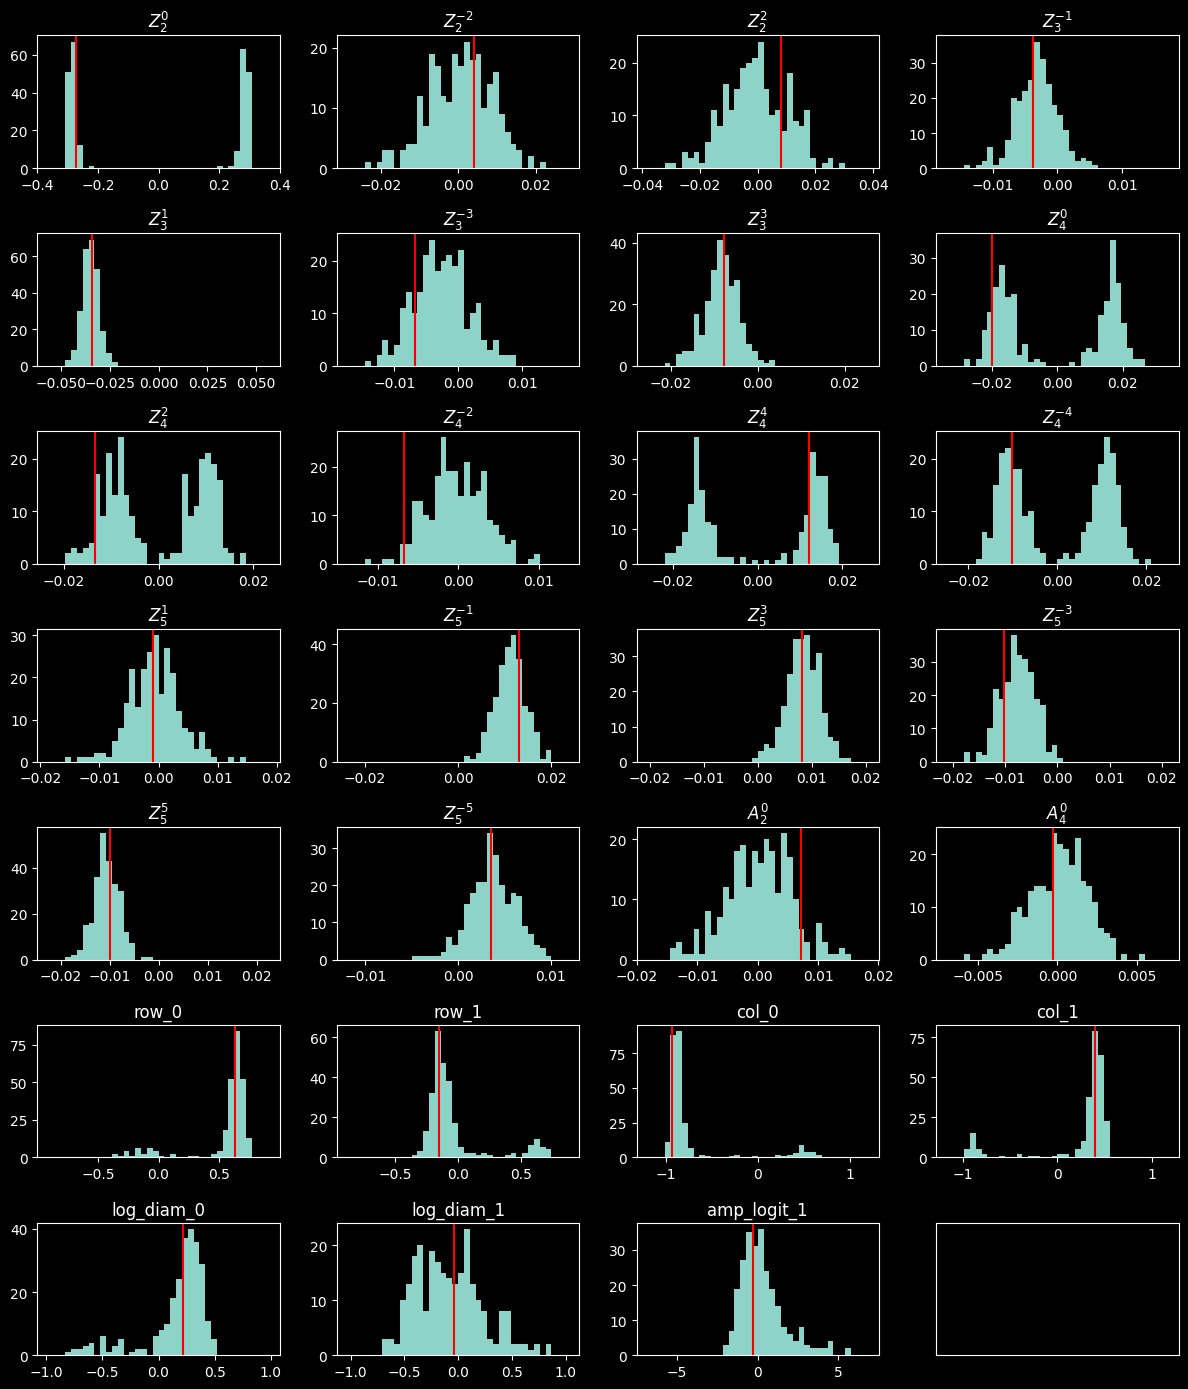

In [11]:
num_plots = solver.coefficients.num_nonpinned_coefs
panel_size = 2
aspect_ratio = 1.5
num_cols = 4
num_rows = int(math.ceil(num_plots / num_cols))
bidx = 2

figsize = (num_cols * panel_size * aspect_ratio, num_rows * panel_size)
fig, axarr = pyplot.subplots(num_rows, num_cols, figsize=figsize)
for i, ax in enumerate(axarr.ravel()):
    if i < num_plots:
        lbl = kept_labels[i]
        target = coefs[bidx, i].numpy(force=True)
        pred_distrib = pred_coefs[bidx, :, i].numpy(force=True)
        bound = np.max(np.abs(pred_distrib))
        _ = ax.hist(pred_distrib, range=(-bound, bound), bins=32)
        ax.axvline(target, color="r")
        ax.set_xlim(-bound*1.3, bound*1.3)
        ax.set_title(lbl)
    else:
        ax.set_xticks([])
        ax.set_yticks([])
fig.tight_layout()

The aberration distributions generally overlap with the true coefficients, modulo the expected two-fold degeneracies for some of the even-n cases.

The object-related parameters also agree well with the predictions. The positional terms show small, secondary peaks mirrored between the two blobs, corresponding to flips in the blob identities so the sampled amplitudes maintain the canonical order.

For each batch element, plot a handful of images from the predicted posterior. They should all look similar to the true image, although some slight variation is reasonable.

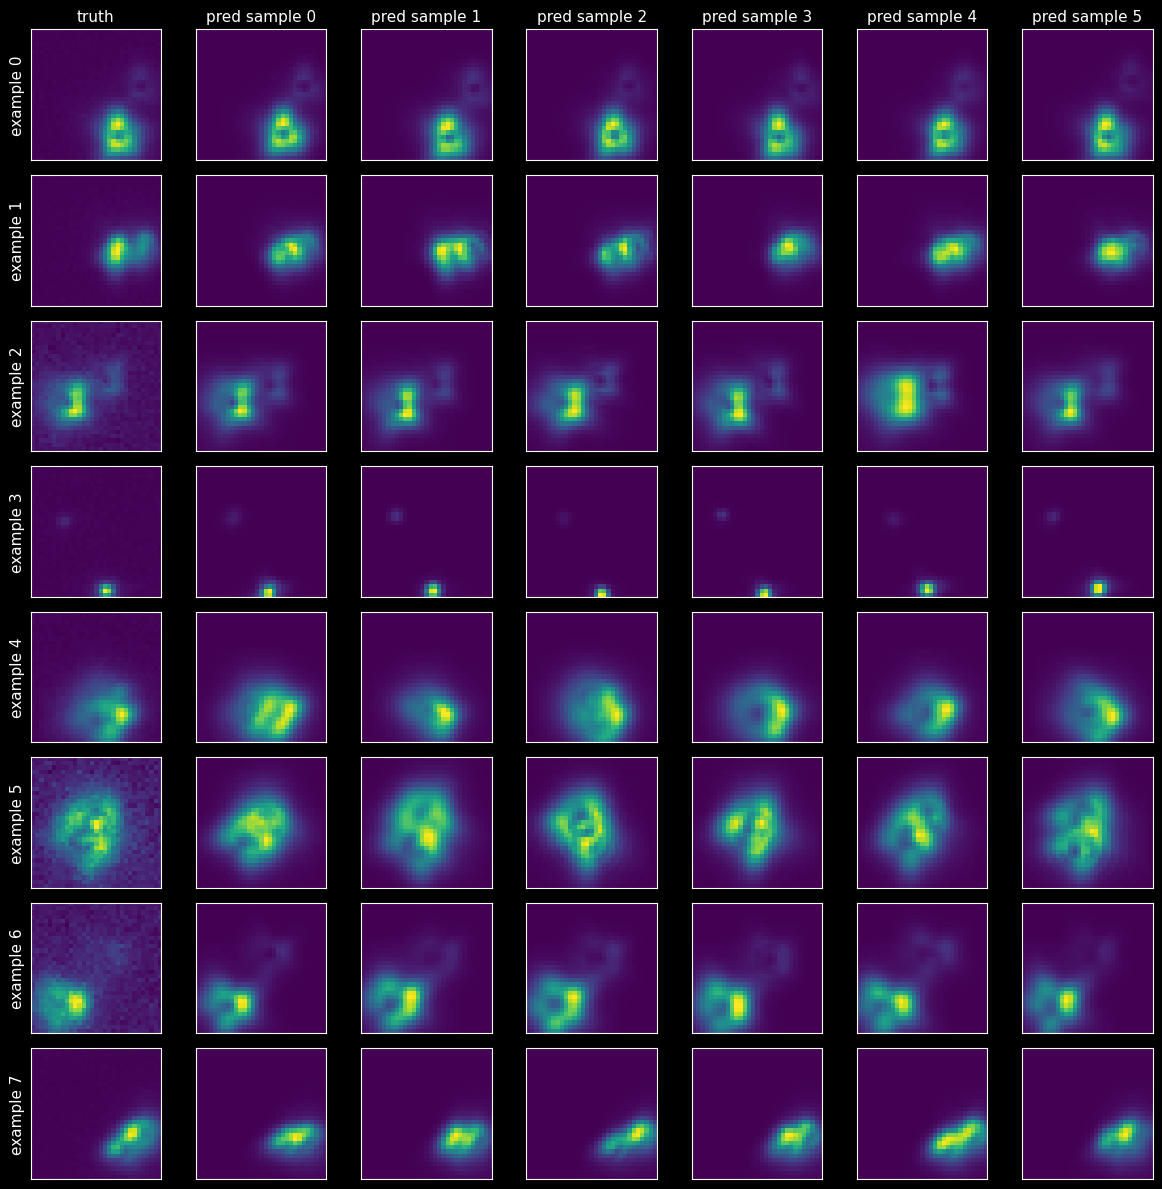

In [12]:
num_samples_to_show = 6
panel_size = 2
fig, axarr = pyplot.subplots(batch_size, 1+num_samples_to_show, figsize=(num_samples_to_show*panel_size, num_samples_to_show*panel_size))
for bidx in range(batch_size):
    axarr[bidx, 0].imshow(images[bidx, 0].numpy(force=True))
    for i in range(num_samples_to_show):
        axarr[bidx, i+1].imshow(pred_images[bidx, i, 0].numpy(force=True))

for ax in axarr.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
for bidx in range(batch_size):
    axarr[bidx, 0].set_ylabel(f"example {bidx}", size=11)
axarr[0, 0].set_title("truth", size=11)
for i in range(num_samples_to_show):
    axarr[0, i+1].set_title(f"pred sample {i}", size=11)
fig.tight_layout()

In [13]:
true_objects = object_distrib.render_from_params(object_params)
pred_objects = object_distrib.render_from_params(pred_object_params)

Make the same kind of plot, this time showing the true vs. predicted objects rather than the aberrated spots. Reconstruction of the objects gets a little shakey when they're close together, probably due to the PSFs blending into one another, but the examples where the beads are well-separated are more stable.

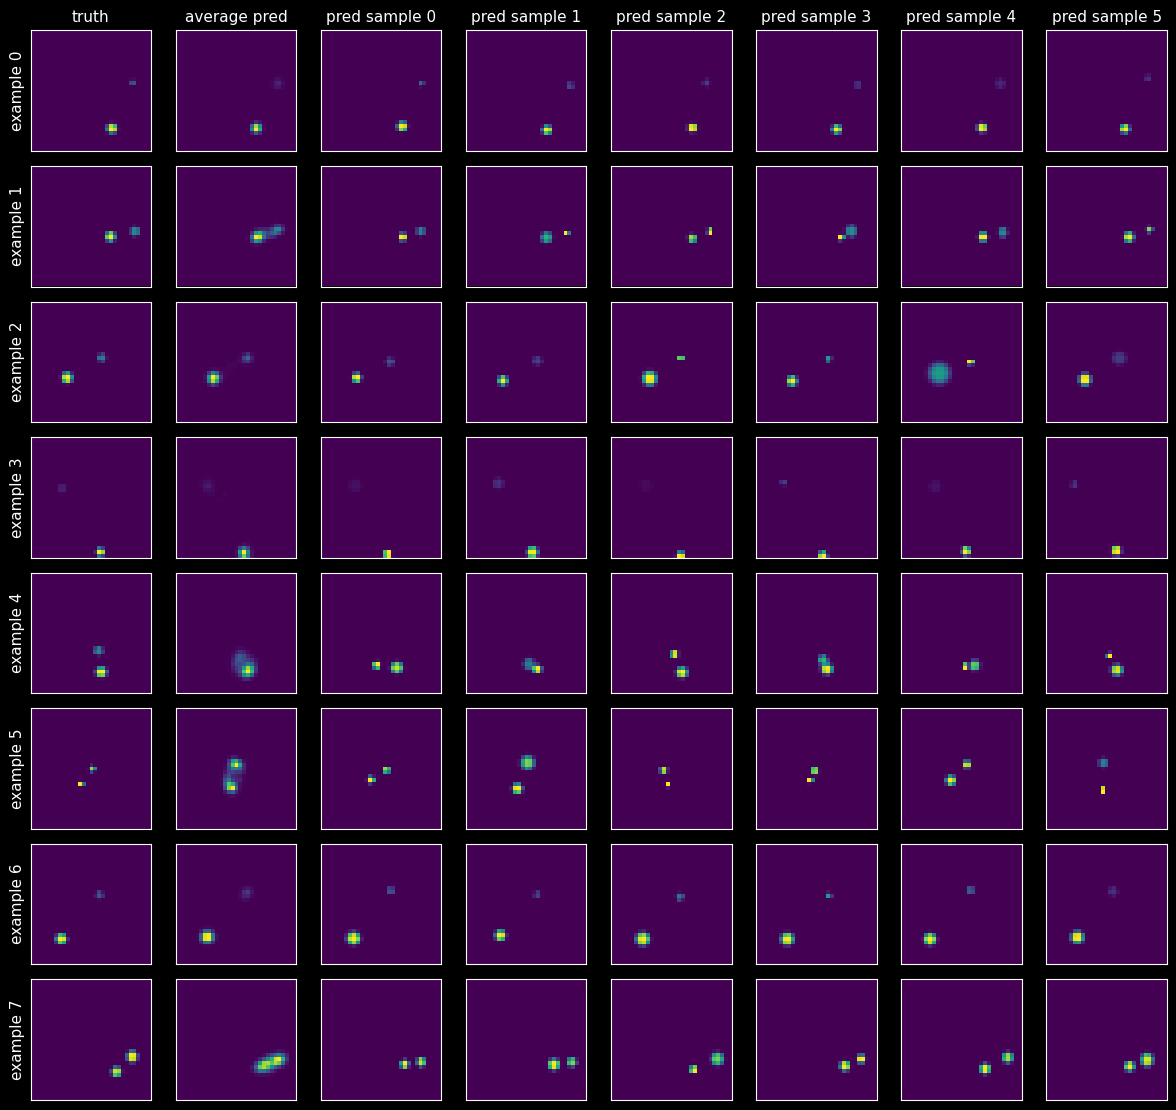

In [14]:
num_samples_to_show = 6
panel_size = 2
fig, axarr = pyplot.subplots(batch_size, 2+num_samples_to_show, figsize=(num_samples_to_show*panel_size, batch_size*panel_size*0.7))
for bidx in range(batch_size):
    axarr[bidx, 0].imshow(true_objects[bidx, 0].numpy(force=True))
    axarr[bidx, 1].imshow(pred_objects[bidx, :, 0].numpy(force=True).mean(0))
    for i in range(num_samples_to_show):
        axarr[bidx, i+2].imshow(pred_objects[bidx, i, 0].numpy(force=True))

for ax in axarr.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
for bidx in range(batch_size):
    axarr[bidx, 0].set_ylabel(f"example {bidx}", size=11)
axarr[0, 0].set_title("truth", size=11)
axarr[0, 1].set_title("average pred", size=11)
for i in range(num_samples_to_show):
    axarr[0, i+2].set_title(f"pred sample {i}", size=11)
fig.tight_layout()

To get a better idea how well the model reconstructed the underlying objects, plot the true objects against the mean of the sampled predictions.

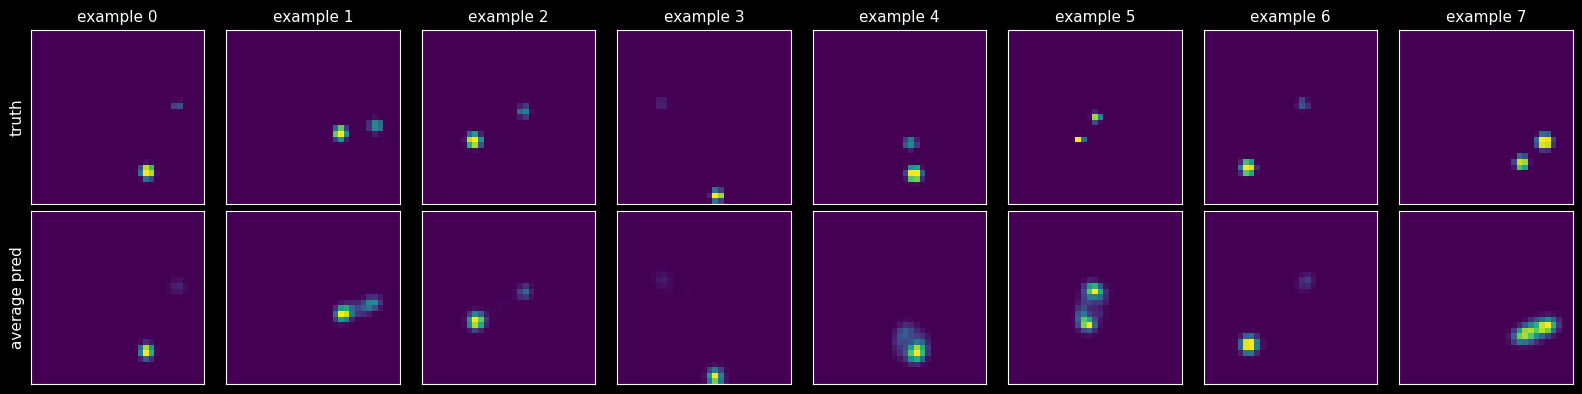

In [15]:
panel_size = 2
fig, axarr = pyplot.subplots(2, batch_size, figsize=(batch_size*panel_size, 2*panel_size))
for bidx in range(batch_size):
    axarr[0, bidx].imshow(true_objects[bidx, 0].numpy(force=True))
    axarr[1, bidx].imshow(pred_objects[bidx, :, 0].numpy(force=True).mean(0))
    axarr[0, bidx].set_title(f"example {bidx}", size=11)

for ax in axarr.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
axarr[0, 0].set_ylabel("truth", size=11)
axarr[1, 0].set_ylabel("average pred", size=11)
fig.tight_layout()